# 3 · Algebraic filters for tensor tomography
Companion notebook to *Fast reconstruction of tensor tomographic X-ray scattering data for real-time applications*
(Antunes, Pelt & Batenburg, Optics Express, [doi:10.1364/OE.597352](https://doi.org/10.1364/OE.597352)).

We reconstruct the simulated projections with $k$ Landweber iterations, compute one algebraic filter per tensor
component (Algorithm 1), and reconstruct again with a single filtering + back-projection step (Algorithm 2),
as in Section 4.1 / Fig. 4. Run notebooks 01 and 02 first.

In [1]:
# Colab only: fetch the repository and install mumott and CuPy (skipped everywhere else)
# Note: mumott 2.1, used for the paper, does not install on Colab's Python version. mumott 2.3 is used instead;
#       its tomographic projector differs slightly, so results can differ from the paper's by a few percent.
import os, sys
if 'google.colab' in sys.modules and not os.getcwd().endswith('notebooks'):
    !git clone -q https://github.com/mesqant/algebraic-filters-tt
    %pip install -q mumott==2.3 cupy-cuda12x colorcet
    %cd algebraic-filters-tt/notebooks

In [2]:
# mumott ≥ 2.2 imports matplotlib.cm.get_cmap, which matplotlib ≥ 3.9 removed (e.g. on Colab); restore it if missing
import matplotlib, matplotlib.cm
if not hasattr(matplotlib.cm, 'get_cmap'):
    matplotlib.cm.get_cmap = matplotlib.colormaps.get_cmap

In [3]:
# Imports (mumott's INFO logging is silenced)
import logging
from functools import partial
from pathlib import Path
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import colorcet  # registers the 'cet_*' colormaps
from tqdm import tqdm
logging.getLogger('mumott').setLevel(logging.WARNING)
from mumott import Geometry
from mumott.methods.projectors import SAXSProjector, SAXSProjectorCUDA

In [4]:
# Compute backend: GPU (cupy + mumott's CUDA projector) if available, else CPU (numpy + mumott's numba projector)
try:
    import cupy as cp
    gpu_available = cp.cuda.runtime.getDeviceCount() > 0
except Exception:
    gpu_available = False
xp = cp if gpu_available else np
to_numpy = cp.asnumpy if gpu_available else np.asarray  # device → host copy (no-op on CPU)
f'GPU: {gpu_available}'

'GPU: True'

In [5]:
# Build the previous notebooks' outputs if they are missing (e.g. on a fresh Colab runtime)
data_dir = Path('../data')
for notebook, output in [('01_representations', 'phantom_representations.npz'), ('02_forward_models', 'geometry.geo')]:
    if not (data_dir / output).exists():
        !jupyter nbconvert --to notebook --execute {notebook}.ipynb --output-dir /tmp

In [6]:
# Load the phantom representations (notebook 01) and mixing operators (notebook 02)
phantom = np.load(data_dir / 'phantom_representations.npz')
mixing = np.load(data_dir / 'mixing_operators.npz')
volume_shape = phantom['tensor'].shape[:3]
{name: mixing[name].shape for name in ['spherical', 'directional', 'tensor']}

{'spherical': (417, 8, 28), 'directional': (417, 8, 7), 'tensor': (417, 3, 6)}

## Forward model (as in notebook 02)

In [7]:
# Acquisition geometry from notebook 02 (resized to the padded volume and subsampled there)
geometry = Geometry(str(data_dir / 'geometry.geo'))
len(geometry)

417

In [8]:
# Tomographic projector W̄, forward model A = W̄Y and adjoint Aᵀ = YᵀW̄ᵀ
projector = SAXSProjectorCUDA(geometry) if gpu_available else SAXSProjector(geometry)

def to_projector(array):  # mumott projectors take host arrays (float32 for CUDA, float64 for CPU)
    return np.asarray(to_numpy(array), dtype=projector.dtype)

def forward(volume, mixing):
    projections = xp.asarray(projector.forward(to_projector(volume)), dtype=xp.float32)
    return xp.einsum('vijc,vsc->vijs', projections, mixing)

def backward(projections, mixing):
    unmixed = xp.einsum('vijs,vsc->vijc', projections, mixing)
    return xp.asarray(projector.adjoint(to_projector(unmixed)), dtype=xp.float32)

In [9]:
# Choose the representation: 'tensor' (C = 6), 'directional' (C = 7) or 'spherical' (C = 28, GPU recommended)
representation = 'tensor'
x_true = xp.asarray(phantom[representation])
Y = xp.asarray(mixing[representation])
A = partial(forward, mixing=Y)
At = partial(backward, mixing=Y)
n_components = x_true.shape[-1]
x_true.shape, Y.shape

((57, 57, 57, 6), (417, 3, 6))

In [10]:
# Simulated projections b = A x_true
b = A(x_true)
b.shape

(417, 57, 57, 3)

## Landweber step size α (power method, Algorithm 1 lines 2–8)

In [11]:
# Estimate λ_max(AᵀA) with 8 power iterations started from the back-projected data
v = At(b)
v /= xp.linalg.norm(v)
lambda_estimates = []
for _ in range(8):
    w = At(A(v))
    lambda_estimates.append(float(xp.vdot(v, w)))  # Rayleigh quotient vᵀAᵀAv
    v = w / xp.linalg.norm(w)
lambda_estimates

[14145.212890625,
 16576.603515625,
 17054.205078125,
 17215.255859375,
 17286.576171875,
 17320.572265625,
 17337.103515625,
 17345.23046875]

'α = 1.095e-04'

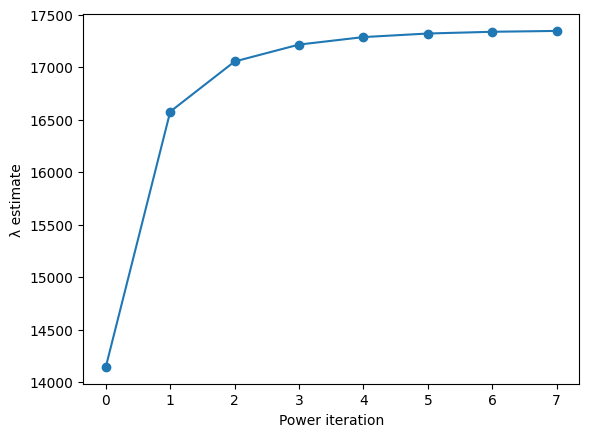

In [12]:
# Show the convergence of the power method and set α close to (but under) the upper bound 2/λ_max
plt.plot(lambda_estimates, 'o-')
plt.xlabel('Power iteration')
plt.ylabel('λ estimate')
alpha = 1.9 / lambda_estimates[-1]
f'α = {alpha:.3e}'

## Landweber reconstruction (Eq. 8)

In [13]:
# Landweber reconstruction Qb = α Σ_i (I − αAᵀA)^i Aᵀb, tracking the data residual
# Note: starting from the i = 0 term αAᵀb, k iterations add k more terms (k+1 in total, vs. i = 0..k−1 in Eq. 10).
#       The filters below use the same convention, so both reconstructions correspond to the same Landweber iterate.
def landweber(b, k):
    term = At(b)
    total = term.copy()
    residual = b.copy()
    residual_norms = []
    for _ in tqdm(range(k), desc='Landweber'):
        forward_term = A(term)
        term -= alpha * At(forward_term)
        total += term
        residual -= alpha * forward_term
        residual_norms.append(float(xp.linalg.norm(residual)))
    return alpha * total, residual_norms

In [14]:
# Reconstruct with k = 50 iterations, as in the paper
k = 50
x_landweber, residual_norms = landweber(b, k)
x_landweber.shape

Landweber:   0%|          | 0/50 [00:00<?, ?it/s]

Landweber:   4%|▍         | 2/50 [00:00<00:02, 17.35it/s]

Landweber:   8%|▊         | 4/50 [00:00<00:02, 17.70it/s]

Landweber:  12%|█▏        | 6/50 [00:00<00:02, 17.51it/s]

Landweber:  16%|█▌        | 8/50 [00:00<00:02, 17.47it/s]

...

Landweber:  92%|█████████▏| 46/50 [00:02<00:00, 17.52it/s]

Landweber:  96%|█████████▌| 48/50 [00:02<00:00, 17.64it/s]

Landweber: 100%|██████████| 50/50 [00:02<00:00, 17.57it/s]

Landweber: 100%|██████████| 50/50 [00:02<00:00, 17.54it/s]

(57, 57, 57, 6)

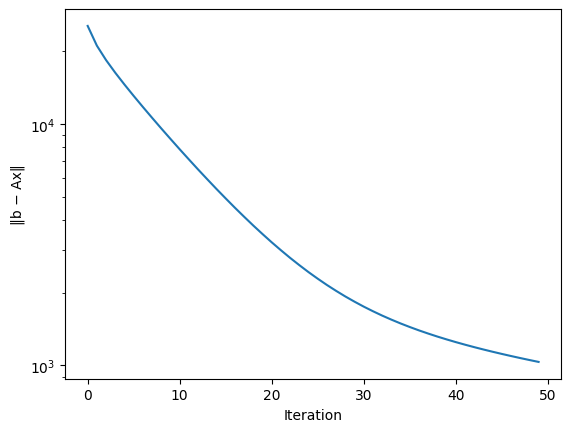

In [15]:
# Show the data residual per iteration
plt.semilogy(residual_norms)
plt.xlabel('Iteration')
plt.ylabel('‖b − Ax‖');

## Algebraic filters (Algorithm 1, lines 9–13)

In [16]:
# Adjoint reconstruction operator Qᵀ = α A Σ_i (I − αAᵀA)^i, applied to a tensor volume (same k+1 term convention)
def landweber_adjoint(volume, k):
    term = volume.copy()
    total = term.copy()
    for _ in tqdm(range(k), desc='Landweber (adjoint)', leave=False):
        term -= alpha * At(A(term))
        total += term
    return alpha * A(total)

In [17]:
# Unit impulse at the central voxel of component c
def central_impulse(c):
    delta = xp.zeros_like(x_true)
    delta[volume_shape[0] // 2, volume_shape[1] // 2, volume_shape[2] // 2, c] = 1
    return delta

In [18]:
# Compute the filter q_c = Qᵀδ_c for every component; filters are written to disk one at a time (low memory),
# and can be reused for any sample measured with this geometry
filters_path = data_dir / f'algebraic_filters_{representation}_{k}iter_{len(geometry)}views.npy'
filters = np.lib.format.open_memmap(filters_path, mode='w+', dtype=np.float32, shape=(n_components,) + b.shape)
for c in tqdm(range(n_components), desc='Filters'):
    filters[c] = to_numpy(landweber_adjoint(central_impulse(c), k))
filters.flush()
filters.shape, f'{filters.nbytes / 1e6:.0f} MB'

Filters:   0%|          | 0/6 [00:00<?, ?it/s]

Landweber (adjoint):   0%|          | 0/50 [00:00<?, ?it/s]

Landweber (adjoint):   4%|▍         | 2/50 [00:00<00:02, 17.30it/s]

Landweber (adjoint):   8%|▊         | 4/50 [00:00<00:02, 17.27it/s]

Landweber (adjoint):  12%|█▏        | 6/50 [00:00<00:02, 17.55it/s]

...

Landweber (adjoint):  96%|█████████▌| 48/50 [00:02<00:00, 17.67it/s]

Landweber (adjoint): 100%|██████████| 50/50 [00:02<00:00, 17.60it/s]

Filters: 100%|██████████| 6/6 [00:17<00:00,  2.88s/it]

Filters: 100%|██████████| 6/6 [00:17<00:00,  2.88s/it]

((6, 417, 57, 57, 3), '98 MB')

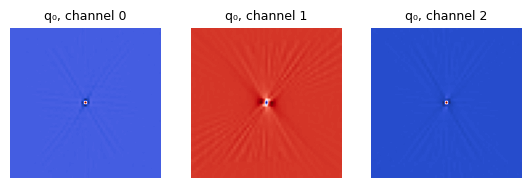

In [19]:
# Show the filter of component 0 for one view, per detector channel
view = len(geometry) // 3
fig, axes = plt.subplots(1, b.shape[-1], figsize=(2.2 * b.shape[-1], 2.4))
for s, ax in enumerate(np.atleast_1d(axes)):
    ax.imshow(filters[0, view, :, :, s].T, cmap='cet_CET_D1A', origin='lower')
    ax.set_title(f'q₀, channel {s}', fontsize=9)
    ax.axis('off')

## Algebraic filter reconstruction (Algorithm 2)

In [20]:
# Filter the projections: for each component c and view, convolve every channel with q_c and sum over channels
b_host = to_numpy(b)
filtered = np.empty(b.shape[:3] + (n_components,), dtype=np.float32)
for c in tqdm(range(n_components), desc='Filtering'):
    for v in range(b.shape[0]):
        filtered[v, :, :, c] = scipy.signal.fftconvolve(b_host[v], filters[c, v], mode='same', axes=(0, 1)).sum(axis=-1)
filtered.shape

Filtering:   0%|          | 0/6 [00:00<?, ?it/s]

Filtering:  17%|█▋        | 1/6 [00:00<00:00,  8.80it/s]

Filtering:  33%|███▎      | 2/6 [00:00<00:00,  8.53it/s]

Filtering:  50%|█████     | 3/6 [00:00<00:00,  8.44it/s]

Filtering:  67%|██████▋   | 4/6 [00:00<00:00,  8.44it/s]

Filtering:  83%|████████▎ | 5/6 [00:00<00:00,  8.59it/s]

Filtering: 100%|██████████| 6/6 [00:00<00:00,  8.69it/s]

Filtering: 100%|██████████| 6/6 [00:00<00:00,  8.60it/s]

(417, 57, 57, 6)

In [21]:
# Back-project all components at once with the plain tomographic back-projector W̄ᵀ
x_af = projector.adjoint(to_projector(filtered)).astype(np.float32)
x_af.shape

(57, 57, 57, 6)

## Comparison with the ground truth and the Landweber reconstruction

In [22]:
# Restrict all volumes to the 'M' mask, on the host
mask = phantom['mask']
volumes = {'Ground truth': to_numpy(x_true), 'Landweber': to_numpy(x_landweber), 'Algebraic filters': x_af}
volumes = {name: np.where(mask[..., None], volume, 0) for name, volume in volumes.items()}

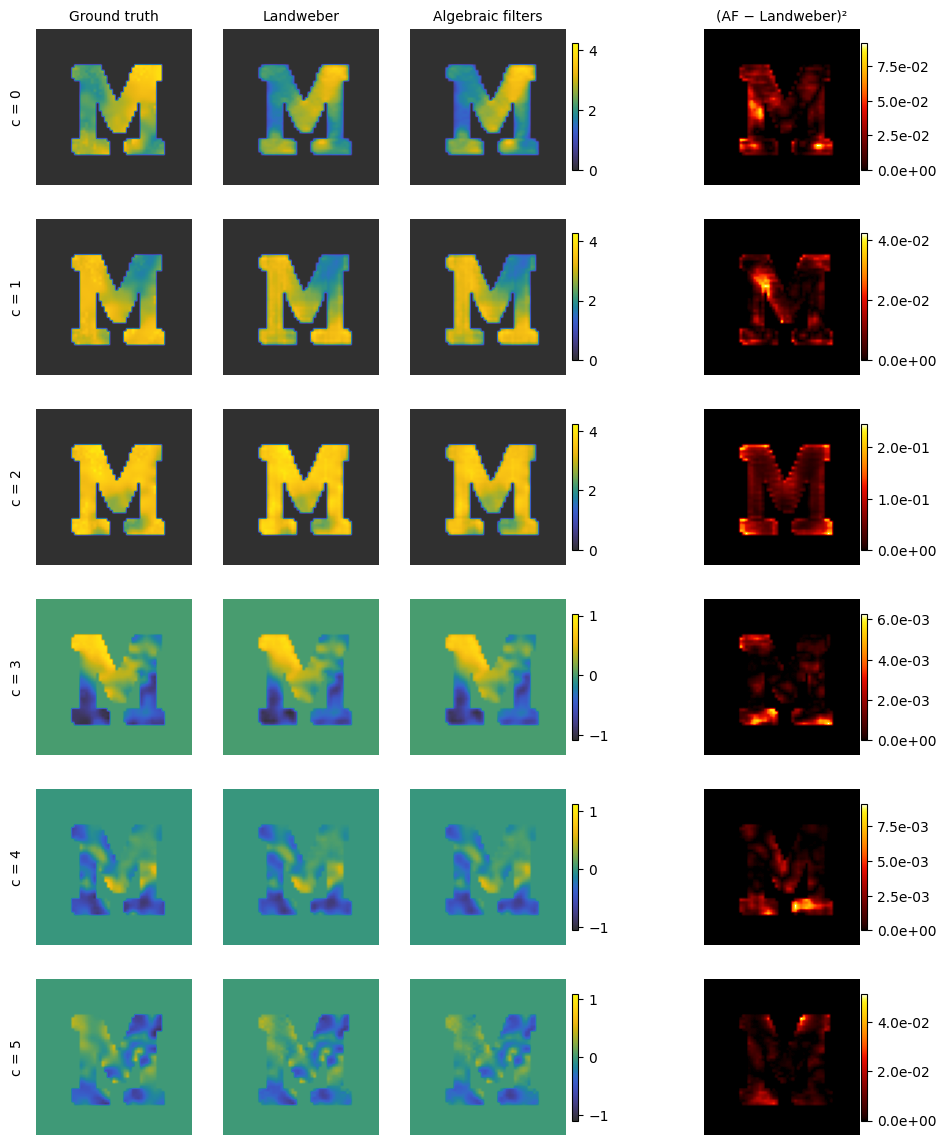

In [23]:
# Show the central slice of up to 6 components (cf. Fig. 4), and the squared AF − Landweber difference
slice_idx = volume_shape[1] // 2
n_shown = min(n_components, 6)
squared_difference = (volumes['Algebraic filters'] - volumes['Landweber']) ** 2
fig, axes = plt.subplots(n_shown, 4, figsize=(11, 2.4 * n_shown), squeeze=False)
for c in range(n_shown):
    vmin, vmax = volumes['Ground truth'][..., c].min(), volumes['Ground truth'][..., c].max()
    for ax, volume in zip(axes[c], volumes.values()):
        im = ax.imshow(volume[:, slice_idx, :, c].T, cmap='cet_gouldian', origin='lower', vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=axes[c, :3], shrink=0.8, pad=0.01)
    im = axes[c, 3].imshow(squared_difference[:, slice_idx, :, c].T, cmap='cet_fire', origin='lower', vmin=0)
    fig.colorbar(im, ax=axes[c, 3], shrink=0.8, pad=0.01, format='%.1e')
    axes[c, 0].text(-0.08, 0.5, f'c = {c}', transform=axes[c, 0].transAxes, rotation=90, va='center', ha='right')
for ax, title in zip(axes[0], list(volumes) + ['(AF − Landweber)²']):
    ax.set_title(title, fontsize=10)
for ax in axes.flat:
    ax.axis('off')

In [24]:
# Mean squared errors inside the mask (cf. Fig. 5 at k = 50)
def masked_mse(x, y):
    return float(np.mean((x[mask] - y[mask]) ** 2))

mse = {'Landweber vs GT': masked_mse(volumes['Landweber'], volumes['Ground truth']),
       'AF vs Landweber': masked_mse(volumes['Algebraic filters'], volumes['Landweber']),
       'AF vs GT': masked_mse(volumes['Algebraic filters'], volumes['Ground truth'])}
{name: f'{value:.3e}' for name, value in mse.items()}

{'Landweber vs GT': '1.059e-01',
 'AF vs Landweber': '1.430e-02',
 'AF vs GT': '1.402e-01'}